In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df_train = pd.read_csv("../data/train.csv")
df_test  = pd.read_csv("../data/test.csv")

print("Train shape:", df_train.shape)
print("Test shape: ", df_test.shape)

Train shape: (103904, 25)
Test shape:  (25976, 25)


In [4]:
df_train.head(7)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,...,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,...,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied


In [5]:
df_train.dtypes

Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

In [6]:
missing = df_train.isnull().sum()
missing[missing > 0]

Arrival Delay in Minutes    310
dtype: int64

In [7]:
df_train.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [8]:
df_train['satisfaction'].value_counts()

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

In [9]:
df_train['satisfaction'].value_counts(normalize=True).round(3) * 100

satisfaction
neutral or dissatisfied    56.7
satisfied                  43.3
Name: proportion, dtype: float64

## Initial data observations

- Dataset has 103,904 training rows and 25 columns
- Only 1 column has missing values: `Arrival Delay in Minutes` (~310 rows, <0.3%)
- 5 columns are text/categorical and will need encoding before ML
- Target is mildly imbalanced: 57% dissatisfied, 43% satisfied
- Service ratings range 0–5; delays have extreme outliers (1500+ min)

In [10]:
df_train['Arrival Delay in Minutes'].fillna(
    df_train['Arrival Delay in Minutes'].median(), inplace=True
)

# confirm it's fixed
df_train.isnull().sum().sum()

C:\Users\likhi\AppData\Local\Temp\ipykernel_18516\4079816810.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Arrival Delay in Minutes'].fillna(


np.int64(0)

In [11]:
df_train['is_dissatisfied'] = (
    df_train['satisfaction'] == 'neutral or dissatisfied'
).astype(int)

df_train['is_dissatisfied'].value_counts()

is_dissatisfied
1    58879
0    45025
Name: count, dtype: int64

Class
Eco         81.4
Eco Plus    75.4
Business    30.6
Name: is_dissatisfied, dtype: float64


C:\Users\likhi\AppData\Local\Temp\ipykernel_18516\2341430596.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_sat.index, y=class_sat.values, palette='Reds_d')


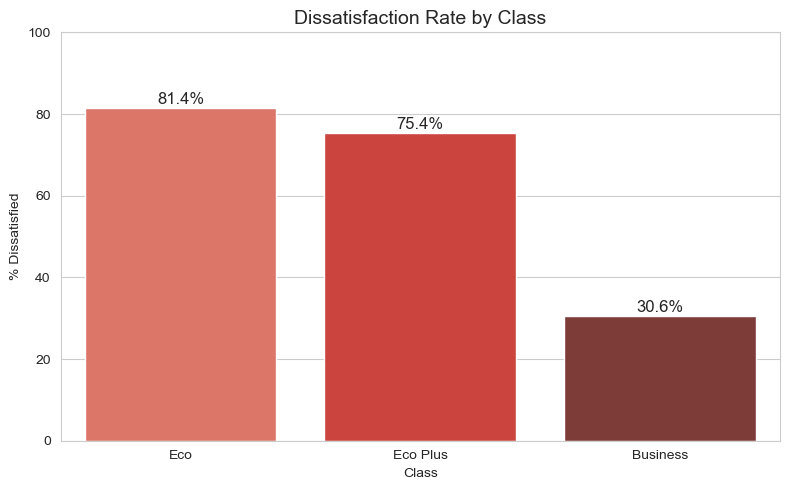

In [12]:
class_sat = df_train.groupby('Class')['is_dissatisfied'].mean() * 100
class_sat = class_sat.round(1).sort_values(ascending=False)
print(class_sat)

plt.figure(figsize=(8, 5))
sns.barplot(x=class_sat.index, y=class_sat.values, palette='Reds_d')
plt.title('Dissatisfaction Rate by Class', fontsize=14)
plt.ylabel('% Dissatisfied')
plt.xlabel('Class')
plt.ylim(0, 100)
for i, v in enumerate(class_sat.values):
    plt.text(i, v + 1, f'{v}%', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('../data/dissatisfaction_by_class.png', dpi=150)
plt.show()

the airline is losing economy passengers at a massive rate while keeping business class passengers relatively happy. Since economy is the highest volume class, that 81.4% represents an enormous number of people who likely won't return or recommend the airline.



Type of Travel
Personal Travel    89.8
Business travel    41.7
Name: is_dissatisfied, dtype: float64


C:\Users\likhi\AppData\Local\Temp\ipykernel_18516\136311783.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=travel_sat.index, y=travel_sat.values, palette='Oranges_d')


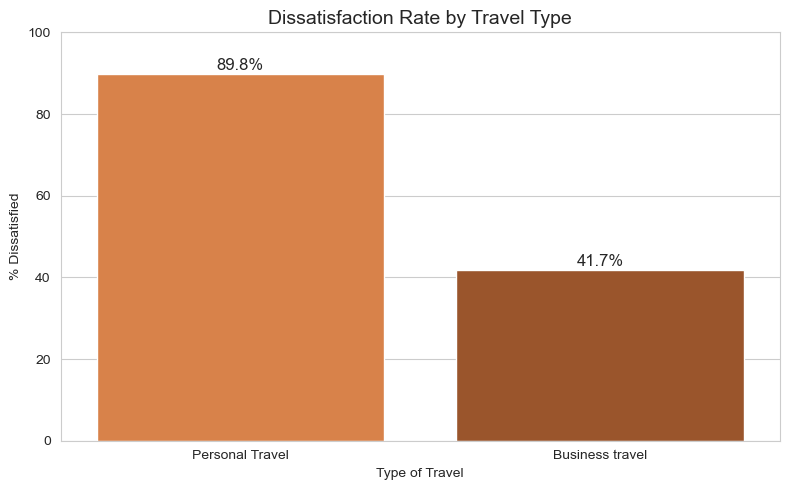

In [13]:
travel_sat = df_train.groupby('Type of Travel')['is_dissatisfied'].mean() * 100
travel_sat = travel_sat.round(1).sort_values(ascending=False)
print(travel_sat)

plt.figure(figsize=(8, 5))
sns.barplot(x=travel_sat.index, y=travel_sat.values, palette='Oranges_d')
plt.title('Dissatisfaction Rate by Travel Type', fontsize=14)
plt.ylabel('% Dissatisfied')
plt.xlabel('Type of Travel')
plt.ylim(0, 100)
for i, v in enumerate(travel_sat.values):
    plt.text(i, v + 1, f'{v}%', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('../data/dissatisfaction_by_travel_type.png', dpi=150)
plt.show()

business travelers fly frequently, their company pays for it, and they usually get better seats. 
Personal travelers are spending their own money, have higher emotional expectations for the experience, and are far less forgiving when something disappoints them.

C:\Users\likhi\AppData\Local\Temp\ipykernel_18516\1644837258.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sat = df_train.groupby('age_group')['is_dissatisfied'].mean() * 100
C:\Users\likhi\AppData\Local\Temp\ipykernel_18516\1644837258.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_sat.index, y=age_sat.values, palette='Blues_d')


age_group
Under 18    82.7
18-30       64.6
31-45       51.3
46-60       42.6
60+         79.2
Name: is_dissatisfied, dtype: float64


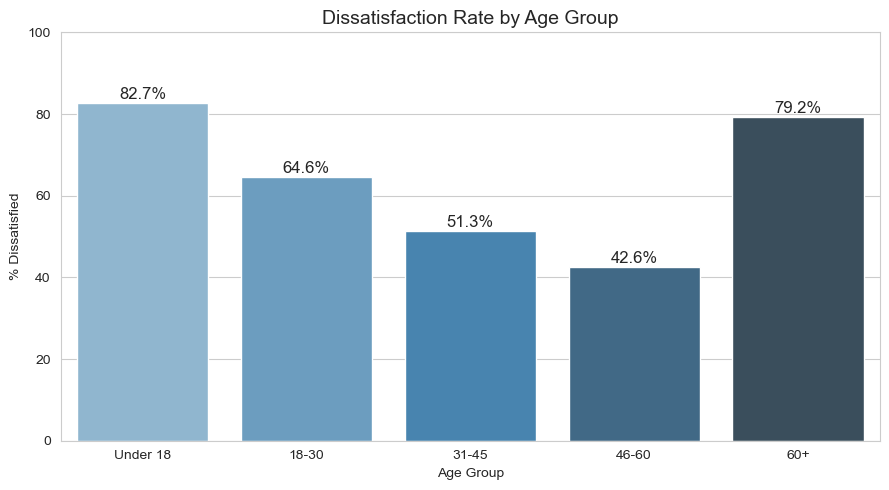

In [14]:
bins = [0, 18, 30, 45, 60, 100]
labels = ['Under 18', '18-30', '31-45', '46-60', '60+']
df_train['age_group'] = pd.cut(df_train['Age'], bins=bins, labels=labels)

age_sat = df_train.groupby('age_group')['is_dissatisfied'].mean() * 100
age_sat = age_sat.round(1)
print(age_sat)

plt.figure(figsize=(9, 5))
sns.barplot(x=age_sat.index, y=age_sat.values, palette='Blues_d')
plt.title('Dissatisfaction Rate by Age Group', fontsize=14)
plt.ylabel('% Dissatisfied')
plt.xlabel('Age Group')
plt.ylim(0, 100)
for i, v in enumerate(age_sat.values):
    plt.text(i, v + 1, f'{v}%', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('../data/dissatisfaction_by_age.png', dpi=150)
plt.show()

## BQ1 Findings — Who is most dissatisfied?

**By Class:**
- Eco: 81.4% dissatisfied
- Eco Plus: 75.4% dissatisfied
- Business: 30.6% dissatisfied

**By Travel Type:**
- Personal Travel: 89.8% dissatisfied
- Business Travel: 41.7% dissatisfied

**By Age Group:**
- Under 18: 82.7% | 18-30: 64.6% | 31-45: 51.3% | 46-60: 42.6% | 60+: 79.2%

**Key Insight:**
The most at-risk passenger is someone flying Economy for personal reasons. 
Nearly 9 in 10 personal travelers are dissatisfied. 
Dissatisfaction drops steadily with age from Under 18 to 46-60, 
then spikes back up at 60+ — suggesting the airline underserves 
both the very young and elderly passengers.    
Middle-aged business travelers (46-60) are the most satisfied group at 42.6%.

In [15]:
service_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

correlations = df_train[service_cols].corrwith(df_train['is_dissatisfied'])
correlations = correlations.sort_values(ascending=False)
print(correlations.round(3))

Departure/Arrival time convenient    0.052
Gate location                       -0.001
Ease of Online booking              -0.172
Food and drink                      -0.210
Checkin service                     -0.236
Inflight service                    -0.245
Baggage handling                    -0.248
Inflight wifi service               -0.284
Cleanliness                         -0.305
Leg room service                    -0.313
On-board service                    -0.322
Seat comfort                        -0.349
Inflight entertainment              -0.398
Online boarding                     -0.504
dtype: float64


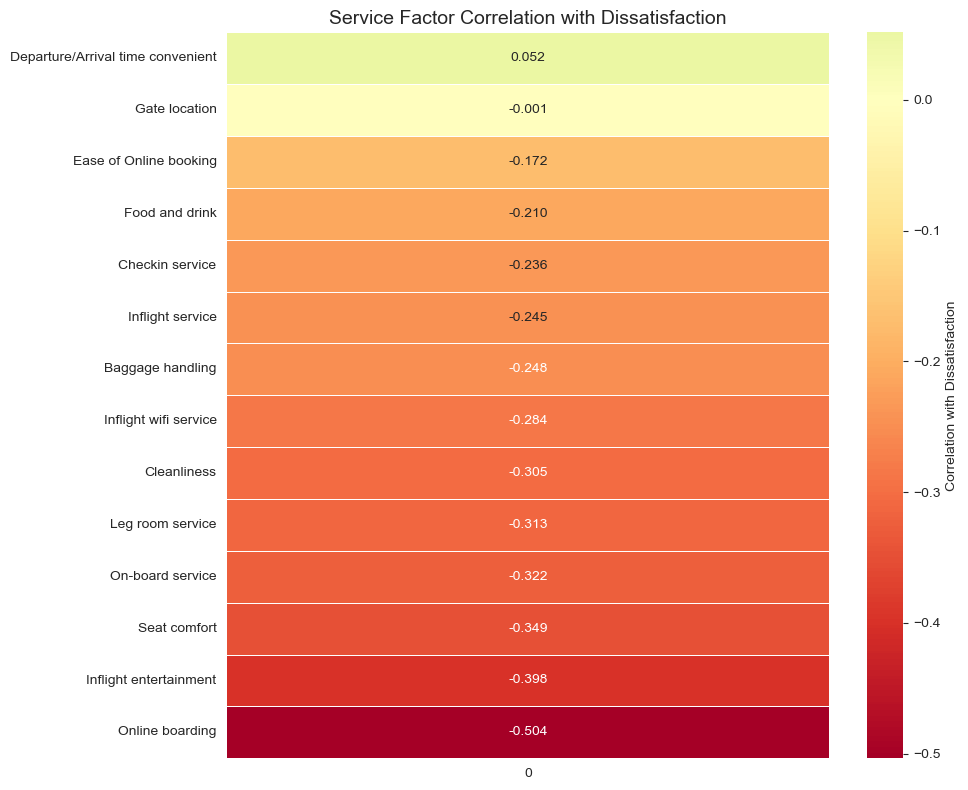

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlations.to_frame(),
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation with Dissatisfaction'}
)
plt.title('Service Factor Correlation with Dissatisfaction', fontsize=14)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()

## BQ2 Findings — What drives dissatisfaction?

Top 3 factors most strongly linked to dissatisfaction:
1. Online boarding (-0.504) — biggest single driver
2. Inflight entertainment (-0.398)
3. Seat comfort (-0.349)

Least impactful: Gate location (-0.001) — barely affects satisfaction at all.

Key insight: The top 3 drivers are all fixable through technology 
and equipment investment — these are actionable recommendations, 
not vague service improvements.

                         Inflight wifi service  \
satisfaction                                     
neutral or dissatisfied                   2.40   
satisfied                                 3.16   

                         Departure/Arrival time convenient  \
satisfaction                                                 
neutral or dissatisfied                               3.13   
satisfied                                             2.97   

                         Ease of Online booking  Gate location  \
satisfaction                                                     
neutral or dissatisfied                    2.55           2.98   
satisfied                                  3.03           2.98   

                         Food and drink  Online boarding  Seat comfort  \
satisfaction                                                             
neutral or dissatisfied            2.96             2.66          3.04   
satisfied                          3.52             4.03       

<Figure size 1200x600 with 0 Axes>

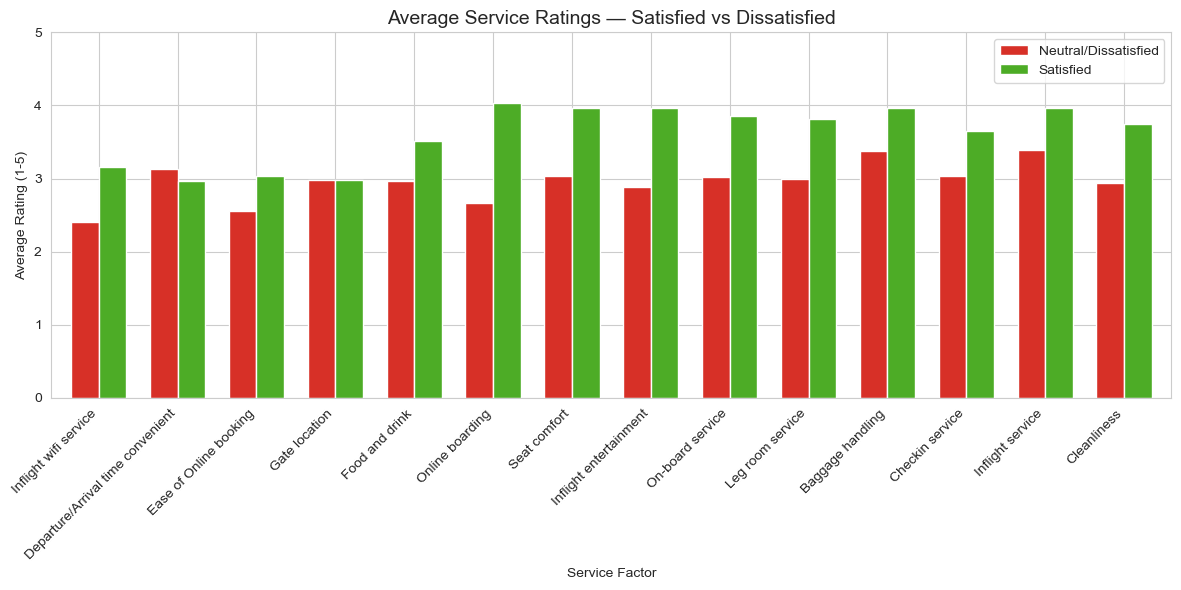

In [17]:
avg_ratings = df_train.groupby('satisfaction')[service_cols].mean().round(2)
print(avg_ratings)

plt.figure(figsize=(12, 6))
avg_ratings.T.plot(kind='bar', figsize=(12, 6), color=['#d73027', '#4dac26'], width=0.7)
plt.title('Average Service Ratings — Satisfied vs Dissatisfied', fontsize=14)
plt.ylabel('Average Rating (1-5)')
plt.xlabel('Service Factor')
plt.xticks(rotation=45, ha='right')
plt.legend(['Neutral/Dissatisfied', 'Satisfied'])
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('../data/avg_ratings_comparison.png', dpi=150)
plt.show()

## BQ2 Additional Finding — Rating Gaps

Satisfied passengers rate Online boarding ~1.4 points higher than 
dissatisfied passengers — the largest gap of all 14 factors.
Gate location shows almost no gap — lowest priority for improvement.

Recommendation: Prioritise online boarding, inflight entertainment, 
and seat comfort for maximum impact on satisfaction scores.

In [18]:
# define revenue per class
revenue_map = {
    'Business': 500,
    'Eco Plus': 250,
    'Eco': 150
}

# map revenue to each passenger
df_train['revenue_per_passenger'] = df_train['Class'].map(revenue_map)

# calculate revenue at risk per passenger
df_train['revenue_at_risk'] = df_train['is_dissatisfied'] * df_train['revenue_per_passenger']

# summarise by class
revenue_summary = df_train.groupby('Class')['revenue_at_risk'].sum().reset_index()
revenue_summary.columns = ['Class', 'revenue_at_risk']
revenue_summary = revenue_summary.sort_values('revenue_at_risk', ascending=False)

print(revenue_summary)
print(f"\nTotal revenue at risk: ${revenue_summary['revenue_at_risk'].sum():,.0f}")

      Class  revenue_at_risk
0  Business          7592500
1       Eco          5706600
2  Eco Plus          1412500

Total revenue at risk: $14,711,600


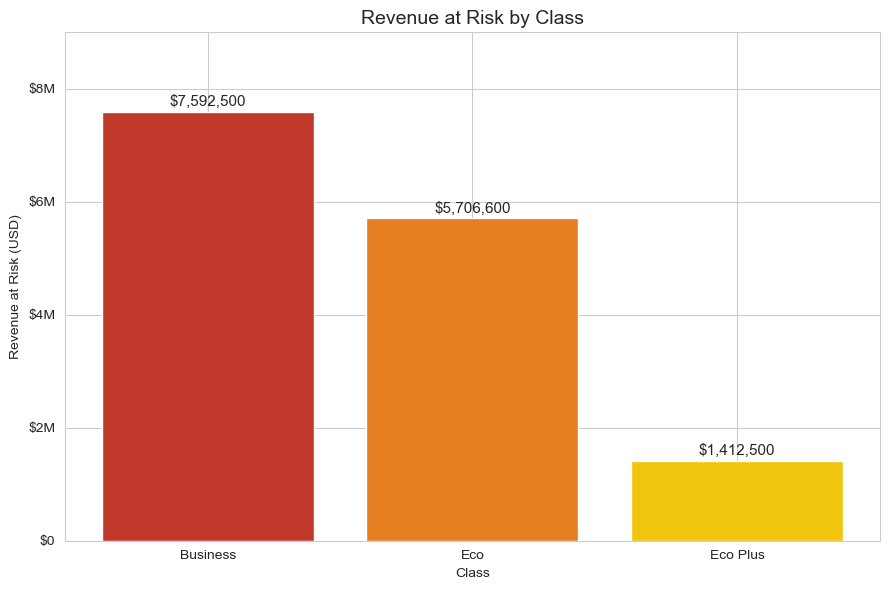

In [19]:
plt.figure(figsize=(9, 6))
colors = ['#c0392b', '#e67e22', '#f1c40f']
bars = plt.bar(revenue_summary['Class'], revenue_summary['revenue_at_risk'], color=colors)

plt.title('Revenue at Risk by Class', fontsize=14)
plt.ylabel('Revenue at Risk (USD)')
plt.xlabel('Class')
plt.ylim(0, 9000000)
plt.yticks([0, 2000000, 4000000, 6000000, 8000000],
           ['$0', '$2M', '$4M', '$6M', '$8M'])


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100000,
             f'${height:,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/revenue_at_risk.png', dpi=150)
plt.show()

## BQ4 Findings — Financial Cost of Dissatisfaction

| Class    | Dissatisfied Passengers | Revenue at Risk |
|----------|------------------------|-----------------|
| Business | 15,185                 | $7,592,500      |
| Eco      | 38,044                 | $5,706,600      |
| Eco Plus | 5,650                  | $1,412,500      |

Total revenue at risk: $14,711,600

Note: Revenue per passenger estimated using industry averages
(Business: $500, Eco Plus: $250, Eco: $150).

Key insight: Business class has the lowest dissatisfaction rate (30.6%)
but the highest revenue at risk ($7.5M) — each dissatisfied Business 
passenger costs more than 3 Economy passengers combined.

In [20]:
loyalty_sat = df_train.groupby('Customer Type')['is_dissatisfied'].mean() * 100
print(loyalty_sat.round(1))

Customer Type
Loyal Customer       52.3
disloyal Customer    76.3
Name: is_dissatisfied, dtype: float64


In [21]:
# export cleaned data for Power BI
export_cols = [
    'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
    'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness',
    'Departure Delay in Minutes', 'Arrival Delay in Minutes',
    'satisfaction', 'is_dissatisfied', 'age_group',
    'revenue_per_passenger', 'revenue_at_risk'
]

df_train[export_cols].to_csv('../data/cleaned_data.csv', index=False)
print(f"Exported {len(df_train)} rows to cleaned_data.csv")

Exported 103904 rows to cleaned_data.csv


In [22]:
# export correlation data for Power BI
corr_df = pd.DataFrame({
    'Factor': correlations.index,
    'Correlation': correlations.abs().values
})
corr_df = corr_df.sort_values('Correlation', ascending=False)
corr_df.to_csv('../data/correlations.csv', index=False)
print(corr_df)

                               Factor  Correlation
13                    Online boarding     0.503557
12             Inflight entertainment     0.398059
11                       Seat comfort     0.349459
10                   On-board service     0.322383
9                    Leg room service     0.313131
8                         Cleanliness     0.305198
7               Inflight wifi service     0.284245
6                    Baggage handling     0.247749
5                    Inflight service     0.244741
4                     Checkin service     0.236174
3                      Food and drink     0.209936
2              Ease of Online booking     0.171705
0   Departure/Arrival time convenient     0.051601
1                       Gate location     0.000682


In [23]:
revenue_summary = df_train.groupby('Class')['revenue_at_risk'].sum().reset_index()
revenue_summary.columns = ['Class', 'revenue_at_risk']
revenue_summary = revenue_summary.sort_values('revenue_at_risk', ascending=False)
revenue_summary.to_csv('../data/revenue_summary.csv', index=False)
print(revenue_summary)

      Class  revenue_at_risk
0  Business          7592500
1       Eco          5706600
2  Eco Plus          1412500
